In [ ]:
# Path shim: this notebook lives in supplementary/, but imports and data/
# checkpoint paths throughout the pipeline are relative to the repo root.
import os, sys
_PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
os.chdir(_PROJECT_ROOT)
sys.path.insert(0, _PROJECT_ROOT)


In [1]:
import utils_inverse
import utils_plotting
%load_ext autoreload
%autoreload 2

# Use inverse model to find optimal emissions time series for N<sub>2</sub>O

## 1. Generate initial parameters, test backpropagation, and create baseline emulator

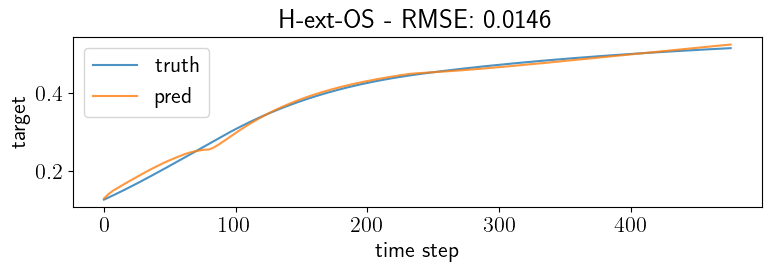

Getting gradient for historical...
	||grad BC||: 0.0
	||grad CH4||: 0.0
	||grad CO2||: 0.0
	||grad N2O||: 0.0004070528957527131
	||grad Sulfur||: 0.0


In [2]:
# Required to generate baseline parameters
agents        = ['N2O']       # Forcing agents included in temperatutre simulations
active_agents = ("N2O",)       # Forcing agents with active gradients (can differ from above)
hidden_sizes  = [16]          # Dimension of neural network emulator
idx_demo      = 1             # Index of scenario to plot
test_scen     = 'historical'  # Scenario to test backpropagation; gradient printed wrt this scenario
verbose       = False         # Flag to print RMSE values for test

# Generate initial parameters and test backpropagation
params0, emis_dict_train_JAX = utils_inverse.generate_init_params_and_train_data(agents,
                                                                                 active_agents,
                                                                                 test_scen,
                                                                                 hidden_sizes=hidden_sizes,
                                                                                 idx_demo=idx_demo,
                                                                                 verbose=verbose)

In [3]:
# Generate data for emulator evaluation
(eval_sets,
emis_dict_tier1_JAX,
emis_dict_tier2_JAX,
emis_dict_DECK_JAX,
emis_dict_CS3_JAX,
emis_dict_all_JAX) = utils_inverse.generate_eval_data(agents, CS3=True, DAMIP=False, GeoMIP=False)

In [4]:
# Baseline emulator parameters
save_path   = 'checkpoints/n2o/baseline_n2o_only.pkl' # Location to save baseline data
verbose     = False # Flag to print NRMSE values from the baseline emulator

# Create baseline emulator
baseline_results, baseline_pred_delT, ground_truth_delT = utils_inverse.generate_and_eval_baseline_emulator(emis_dict_tier1_JAX,
                                                                                                            eval_sets, save_path=save_path,
                                                                                                            verbose=verbose, hidden_sizes=hidden_sizes)

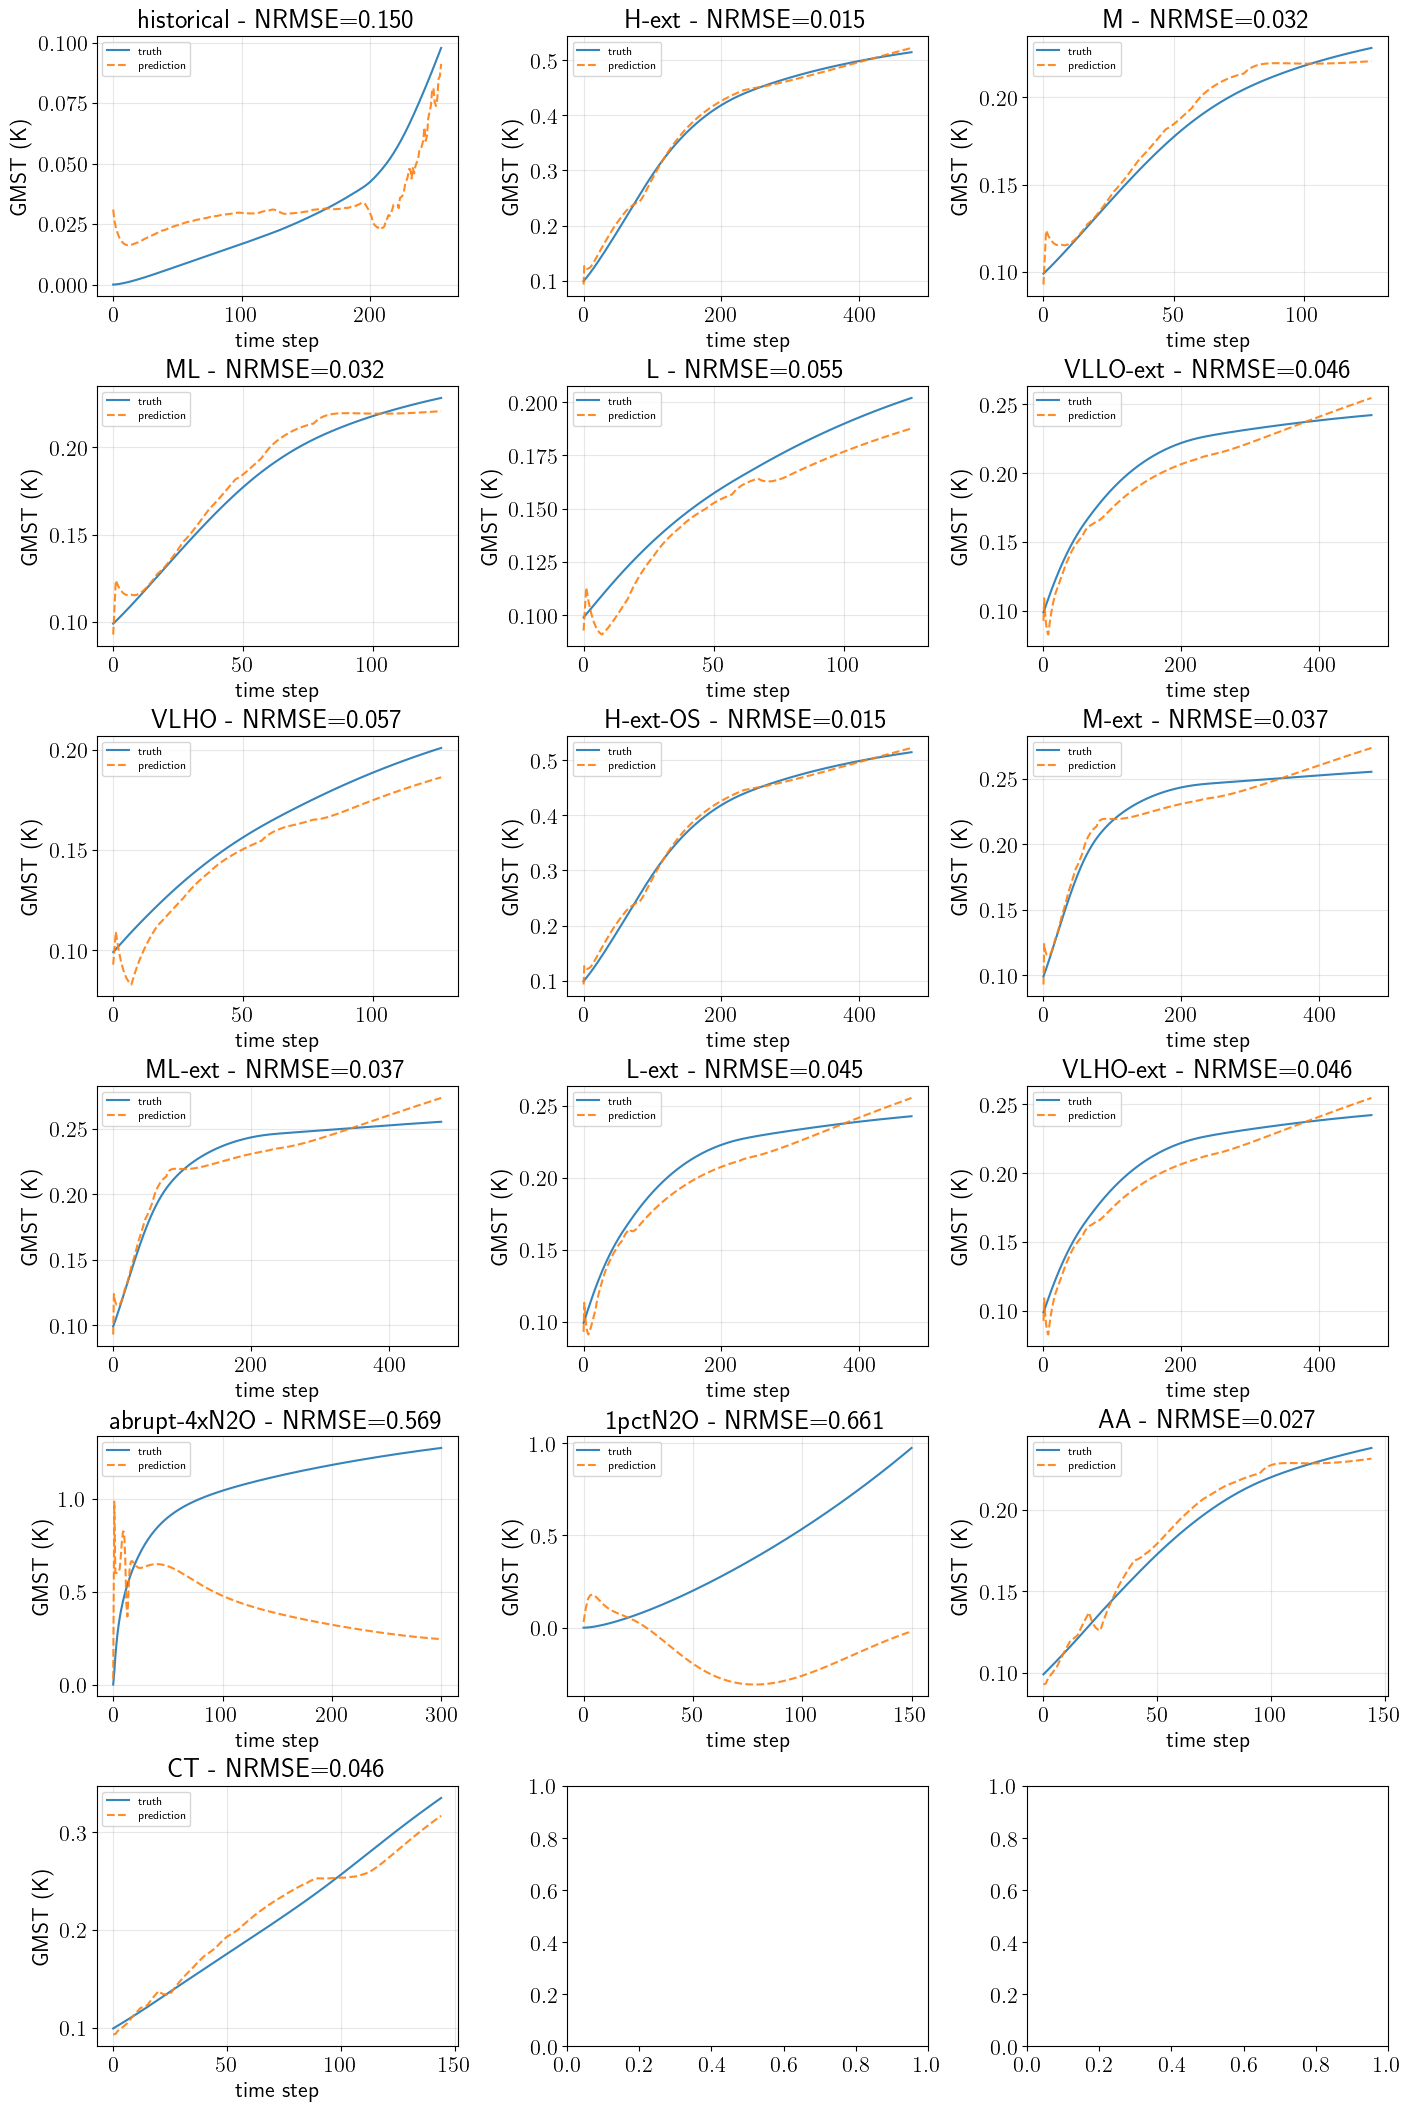

In [5]:
# Optional: plot predictions of baseline emulator
utils_plotting.plot_baseline_pred_delT(baseline_results, baseline_pred_delT, ground_truth_delT)

## 2. Optimize N<sub>2</sub>O emissions time series used in training

### 2a. Optimize for individual scenario (H-ext), starting from constant initial condition

In [ ]:
# Compute migrated to scripts/supplementary/SIb_inverse_N2O_only.py (run standalone / scheduled) - this cell just loads the resulting checkpoint.
results_N2O_Hext_const = utils_inverse.load_inverse_ckpt('checkpoints/n2o/inverse_constant_H-ext_n2o_only.pkl')


In [ ]:
# Optional: plot results of optimization
predict_plot = 'H-ext'

utils_plotting.plot_inverse_results(
    results_N2O_Hext_const,
    baseline_results['Tier 1'][predict_plot],
    active_agents=('N2O',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_pred_delT['Tier 1'][predict_plot]
)

### 2b. Optimize training data for predictive skill over all evaluation sets

In [ ]:
# Compute migrated to scripts/supplementary/SIb_inverse_N2O_only.py (run standalone / scheduled) - this cell just loads the resulting checkpoints.
results_N2O_dict = {
    'tier1': utils_inverse.load_inverse_ckpt('checkpoints/n2o/inverse_constant_tier1_n2o_only.pkl'),
    'tier2': utils_inverse.load_inverse_ckpt('checkpoints/n2o/inverse_constant_tier2_n2o_only.pkl'),
    'DECK': utils_inverse.load_inverse_ckpt('checkpoints/n2o/inverse_constant_DECK_n2o_only.pkl'),
    'CS3': utils_inverse.load_inverse_ckpt('checkpoints/n2o/inverse_constant_CS3_n2o_only.pkl'),
    'all': utils_inverse.load_inverse_ckpt('checkpoints/n2o/inverse_constant_all_n2o_only.pkl')
}


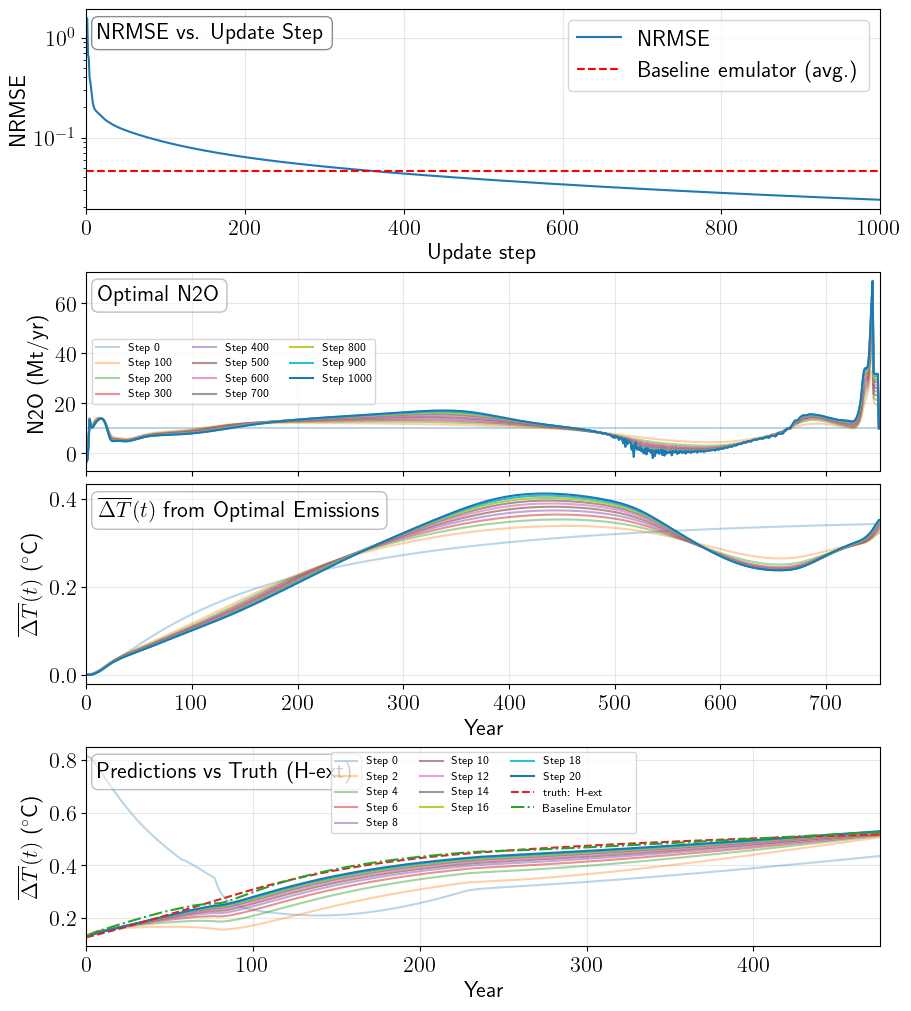

In [8]:
# Optional: plot results of optimization
## Plotting parameters
opt_test        = 'tier1'  # Evaluation set to plot optimized results for
baseline_test   = 'Tier 1' # Evaluation set to plot results for
predict_plot    = 'H-ext'  # Individual scenario to plot predictions

utils_plotting.plot_inverse_results(
    results_N2O_dict[opt_test],
    baseline_results[baseline_test]['mean'],
    active_agents=active_agents,
    pred_scenario=predict_plot,
    baseline_preds=baseline_pred_delT[baseline_test][predict_plot]
)